3. Xây dựng mô hình

 Mục tiêu: Xây dựng và đánh giá các mô hình ML cho bài toán phân loại bệnh tim

*1. thư viện và import model*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             roc_curve)

# Đồ thị
import matplotlib.pyplot as plt
import seaborn as sns

# Khác
import joblib
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho đồ thị
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Thư viện đã được import thành công!")

Thư viện đã được import thành công!


In [4]:
import pandas as pd

data = pd.read_csv("E:/AI_du_doan_benh_tim_mach/data/data_process/heart_disease_processed_on_train")
print(data.head())

   id       age  sex  trestbps      chol  fbs    thalch  exang   oldpeak  \
0   1  1.007386    1  0.717803 -0.163493    1  0.489727      0  1.368109   
1   2  1.432034    1  1.554856  0.844082    0 -1.181478      1  0.611589   
2   3  1.432034    1 -0.677285 -0.239537    0 -0.345875      1  1.651804   
3   4 -1.752828    1 -0.119250  0.159691    0  1.961979      0  2.502889   
4   5 -1.328180    0 -0.119250 -0.714808    0  1.365120      0  0.517024   

   ca_missing  ...  age_>60  age_<40.1  age_40-50.1  age_50-60.1  age_>60.1  \
0           0  ...    False       True        False        False      False   
1           0  ...    False       True        False        False      False   
2           0  ...    False       True        False        False      False   
3           0  ...    False      False        False        False      False   
4           0  ...    False      False        False        False      False   

   age_<40.2  age_40-50.2  age_50-60.2  age_>60.2  risk_score_binary

In [5]:
data.shape

(920, 37)

In [6]:
print(data.info())


<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        920 non-null    int64  
 1   age                       920 non-null    float64
 2   sex                       920 non-null    int64  
 3   trestbps                  920 non-null    float64
 4   chol                      920 non-null    float64
 5   fbs                       920 non-null    int64  
 6   thalch                    920 non-null    float64
 7   exang                     920 non-null    int64  
 8   oldpeak                   920 non-null    float64
 9   ca_missing                920 non-null    int64  
 10  thal_missing              920 non-null    int64  
 11  cp_atypical angina        920 non-null    bool   
 12  cp_non-anginal            920 non-null    bool   
 13  cp_typical angina         920 non-null    bool   
 14  restecg_normal       

In [7]:
print(data.describe())


               id           age         sex      trestbps          chol  \
count  920.000000  9.200000e+02  920.000000  9.200000e+02  9.200000e+02   
mean   460.500000  6.178632e-17    0.789130 -3.514097e-16  1.158494e-16   
std    265.725422  1.000544e+00    0.408148  1.000544e+00  1.000544e+00   
min      1.000000 -2.708286e+00    0.000000 -2.909426e+00 -2.977099e+00   
25%    230.750000 -6.912073e-01    1.000000 -6.772850e-01 -4.534087e-01   
50%    460.500000  5.192709e-02    1.000000 -1.192497e-01 -3.536018e-01   
75%    690.250000  6.888994e-01    1.000000  4.387856e-01  4.828755e-01   
max    920.000000  2.493654e+00    1.000000  3.786997e+00  6.870521e+00   

              fbs        thalch       exang       oldpeak  ca_missing  \
count  920.000000  9.200000e+02  920.000000  9.200000e+02   920.00000   
mean     0.150000 -4.325043e-16    0.366304 -7.723291e-18     0.66413   
std      0.357266  1.000544e+00    0.482056  1.000544e+00     0.47255   
min      0.000000 -3.091427e+00 

*2. CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH*


In [8]:
# Tách features (X) và target (y)
X = data.drop(columns=['target', 'id'])  
y = data['target']
data['target'].value_counts()

target
1    509
0    411
Name: count, dtype: int64

In [9]:
print("THÔNG TIN DỮ LIỆU")
print(f"Features (X): {X.shape[1]} đặc trưng")
print(f"Target (y): {y.value_counts().to_dict()}")
print(f"Tỷ lệ có bệnh: {y.mean()*100:.2f}%")
print(f"Tỷ lệ không bệnh: {(1-y.mean())*100:.2f}%")

# Kiểm tra missing values (đảm bảo không còn)
print(f"Missing values trong X: {X.isnull().sum().sum()}")

THÔNG TIN DỮ LIỆU
Features (X): 35 đặc trưng
Target (y): {1: 509, 0: 411}
Tỷ lệ có bệnh: 55.33%
Tỷ lệ không bệnh: 44.67%
Missing values trong X: 0


*3. chia tập train test 80/20*

In [10]:
# Chia dữ liệu với stratify để giữ tỷ lệ target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,            
    random_state=42,         
    stratify=y               
)


In [11]:
print(f"Kích thước tập huấn luyện: {X_train.shape[0]} mẫu")
print(f"Kích thước tập kiểm tra: {X_test.shape[0]} mẫu")
print(f"Tỷ lệ có bệnh trong tập huấn luyện: {y_train.mean()*100:.2f}%")
print(f"Tỷ lệ có bệnh trong tập kiểm tra: {y_test.mean()*100:.2f}%")
print(f"tỷ lệ không	bệnh trong tập huấn luyện: {(1-y_train.mean())*100:.2f}%")
print(f"tỷ lệ không	bệnh trong tập kiểm tra: {(1-y_test.mean())*100:.2f}%")

Kích thước tập huấn luyện: 736 mẫu
Kích thước tập kiểm tra: 184 mẫu
Tỷ lệ có bệnh trong tập huấn luyện: 55.30%
Tỷ lệ có bệnh trong tập kiểm tra: 55.43%
tỷ lệ không	bệnh trong tập huấn luyện: 44.70%
tỷ lệ không	bệnh trong tập kiểm tra: 44.57%


*4. cross - validation (k-fold)*

In [12]:
#cross	validation	với StratifiedKFold
#cấu hình	cross-validation
#tham số 
k = 10

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print(f"Đã thiết lập StratifiedKFold với {k} folds và random_state=42")

Đã thiết lập StratifiedKFold với 10 folds và random_state=42


In [13]:
# 5. ĐỊNH NGHĨA CÁC MÔ HÌNH CẦN THỬ NGHIỆM
# k =	10 cho cross-validation

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

print("CÁC MÔ HÌNH SẼ ĐƯỢC THỬ NGHIỆM")
for name in models.keys():
    print(f"   • {name}")
    
print("tham số k cho cross-validation đã được thiết lập là:", k)

CÁC MÔ HÌNH SẼ ĐƯỢC THỬ NGHIỆM
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • KNN
   • SVM
   • XGBoost
   • LightGBM
tham số k cho cross-validation đã được thiết lập là: 10


*5. cân bằng dữ liệu SMOTE*

In [14]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [15]:
print(data.columns)

Index(['id', 'age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang',
       'oldpeak', 'ca_missing', 'thal_missing', 'cp_atypical angina',
       'cp_non-anginal', 'cp_typical angina', 'restecg_normal',
       'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping',
       'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach',
       'target', 'bp_age_ratio', 'risk_score', 'age_<40', 'age_40-50',
       'age_50-60', 'age_>60', 'age_<40.1', 'age_40-50.1', 'age_50-60.1',
       'age_>60.1', 'age_<40.2', 'age_40-50.2', 'age_50-60.2', 'age_>60.2',
       'risk_score_binary'],
      dtype='str')


In [16]:
#sử dụng smote	để cân bằng dữ liệu huấn luyện
smote	= SMOTE(random_state=42)	
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [17]:
# PHÂN LOẠI CỘT: SỐ LIÊN TỤC vs BINARY

# Danh sách cột số liên tục (numeric)
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 
                'bp_age_ratio', 'risk_score', 'risk_score_binary']

# Danh sách cột binary (0/1) - TẤT CẢ các cột còn lại
binary_cols = [col for col in X_train.columns if col not in numeric_cols]

print("📊 PHÂN LOẠI CỘT DỮ LIỆU")
print(f"Cột số liên tục ({len(numeric_cols)} cột):")
print(numeric_cols)

print(f"Cột binary ({len(binary_cols)} cột):")
print(binary_cols[:10])  # In 10 cột đầu
print(f"... và {len(binary_cols) - 10} cột khác")

📊 PHÂN LOẠI CỘT DỮ LIỆU
Cột số liên tục (8 cột):
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'bp_age_ratio', 'risk_score', 'risk_score_binary']
Cột binary (27 cột):
['sex', 'fbs', 'exang', 'ca_missing', 'thal_missing', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality']
... và 17 cột khác


In [18]:
# Kiểm tra phân phối trước SMOTE
print("Phân phối trước SMOTE:")
print(f"Train - Có bệnh: {Counter(y_train)[1]}, Không bệnh: {Counter(y_train)[0]}")
print(f"Tỷ lệ có bệnh: {y_train.mean()*100:.2f}%")


Phân phối trước SMOTE:
Train - Có bệnh: 407, Không bệnh: 329
Tỷ lệ có bệnh: 55.30%


In [19]:
# # Sau khi SMOTE
# X_train_numeric_resampled, y_train_resampled = smote.fit_resample(X_train_numeric, y_train)

# # Reset index để khớp
# X_train_numeric_resampled = pd.DataFrame(X_train_numeric_resampled, columns=X_train_numeric.columns)
# y_train_resampled = pd.Series(y_train_resampled)

# # Ghép lại với binary features (lấy theo thứ tự, không theo index gốc)
# X_train_binary_resampled = X_train[binary_cols].reset_index(drop=True).iloc[:len(X_train_numeric_resampled)]

# # Kết hợp numeric + binary
# X_train_resampled = pd.concat([X_train_numeric_resampled, X_train_binary_resampled], axis=1)

# print("Phân phối sau SMOTE:")
# print(f"Train - Có bệnh: {Counter(y_train_resampled)[1]}, Không bệnh: {Counter(y_train_resampled)[0]}")
# print(f"Tỷ lệ có bệnh: {y_train_resampled.mean()*100:.2f}%")

*5. So sánh 2 bản dữ liệu giữa smote với không smote*

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
print(X_train_resampled.isnull().sum().sum())

0


In [22]:
data.loc[data['id'] == 2106]


,id,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca_missing,...,age_>60,age_<40.1,age_40-50.1,age_50-60.1,age_>60.1,age_<40.2,age_40-50.2,age_50-60.2,age_>60.2,risk_score_binary


In [23]:
data[data.isnull().any(axis=1)]


,id,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca_missing,...,age_>60,age_<40.1,age_40-50.1,age_50-60.1,age_>60.1,age_<40.2,age_40-50.2,age_50-60.2,age_>60.2,risk_score_binary


In [24]:
# Liệt kê tất cả các dòng có ít nhất một giá trị NaN
rows_with_nan = X_train_resampled[X_train_resampled.isnull().any(axis=1)]
print(rows_with_nan.shape)
rows_with_nan.head()


(0, 35)


,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca_missing,thal_missing,...,age_>60,age_<40.1,age_40-50.1,age_50-60.1,age_>60.1,age_<40.2,age_40-50.2,age_50-60.2,age_>60.2,risk_score_binary


*fix NAN*

In [25]:
#áp dụng toàn bộ
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("KẾT QUẢ SMOTE")
print(f"Kích thước: {X_train.shape[0]} → {X_train_resampled.shape[0]} mẫu")
print(f"Tỷ lệ có bệnh sau SMOTE: {y_train_resampled.mean()*100:.2f}%")

KẾT QUẢ SMOTE
Kích thước: 736 → 814 mẫu
Tỷ lệ có bệnh sau SMOTE: 50.00%


In [26]:
#xác định các cột binary (cột	có 2 giá trị duy nhất là	0 và 1)
binary_cols = [col for col in X_train.columns if set(X_train[col].unique()).issubset({0, 1})]
print(f"\nPhát hiện {len(binary_cols)} cột binary")


Phát hiện 27 cột binary


In [27]:
# 3. LÀM TRÒN các cột binary về 0 hoặc 1 (vì SMOTE tạo ra số thập phân)
for col in binary_cols:
    X_train_resampled[col] = X_train_resampled[col].round().astype(int)
    print(f"Đã làm tròn cột '{col}' về 0 hoặc 1")

Đã làm tròn cột 'sex' về 0 hoặc 1
Đã làm tròn cột 'fbs' về 0 hoặc 1
Đã làm tròn cột 'exang' về 0 hoặc 1
Đã làm tròn cột 'ca_missing' về 0 hoặc 1
Đã làm tròn cột 'thal_missing' về 0 hoặc 1
Đã làm tròn cột 'cp_atypical angina' về 0 hoặc 1
Đã làm tròn cột 'cp_non-anginal' về 0 hoặc 1
Đã làm tròn cột 'cp_typical angina' về 0 hoặc 1
Đã làm tròn cột 'restecg_normal' về 0 hoặc 1
Đã làm tròn cột 'restecg_st-t abnormality' về 0 hoặc 1
Đã làm tròn cột 'slope_flat' về 0 hoặc 1
Đã làm tròn cột 'slope_upsloping' về 0 hoặc 1
Đã làm tròn cột 'dataset_Hungary' về 0 hoặc 1
Đã làm tròn cột 'dataset_Switzerland' về 0 hoặc 1
Đã làm tròn cột 'dataset_VA Long Beach' về 0 hoặc 1
Đã làm tròn cột 'age_<40' về 0 hoặc 1
Đã làm tròn cột 'age_40-50' về 0 hoặc 1
Đã làm tròn cột 'age_50-60' về 0 hoặc 1
Đã làm tròn cột 'age_>60' về 0 hoặc 1
Đã làm tròn cột 'age_<40.1' về 0 hoặc 1
Đã làm tròn cột 'age_40-50.1' về 0 hoặc 1
Đã làm tròn cột 'age_50-60.1' về 0 hoặc 1
Đã làm tròn cột 'age_>60.1' về 0 hoặc 1
Đã làm tròn cột

In [28]:
# 4. Kiểm tra không còn NaN
print(f" Kiểm tra NaN: {X_train_resampled.isnull().sum().sum()}")
print(f"X_train_resampled shape: {X_train_resampled.shape}")

 Kiểm tra NaN: 0
X_train_resampled shape: (814, 35)


In [29]:
# 5. Kiểm tra cột binary
print(" Kiểm tra cột binary sau khi làm tròn:")
for col in binary_cols[:5]:
    unique_vals = X_train_resampled[col].unique()
    print(f"  {col}: {sorted(unique_vals)}")

 Kiểm tra cột binary sau khi làm tròn:
  sex: [np.int64(0), np.int64(1)]
  fbs: [np.int64(0), np.int64(1)]
  exang: [np.int64(0), np.int64(1)]
  ca_missing: [np.int64(0), np.int64(1)]
  thal_missing: [np.int64(0), np.int64(1)]


*6. so sánh 2 mô hình logistics có smote và no smote*

In [30]:
# 1. KHÔNG SMOTE - Dùng X_train gốc
model_no_smote = LogisticRegression(max_iter=1000, random_state=42)
model_no_smote.fit(X_train, y_train)

y_pred_no_smote = model_no_smote.predict(X_test)
y_proba_no_smote = model_no_smote.predict_proba(X_test)[:, 1]

In [31]:
# 2. CÓ SMOTE - Dùng X_train_resampled
model_with_smote = LogisticRegression(max_iter=1000, random_state=42)
model_with_smote.fit(X_train_resampled, y_train_resampled)

y_pred_with_smote = model_with_smote.predict(X_test)
y_proba_with_smote = model_with_smote.predict_proba(X_test)[:, 1]

In [32]:
# 3. TẠO BẢNG SO SÁNH
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Without SMOTE': [
        accuracy_score(y_test, y_pred_no_smote),
        precision_score(y_test, y_pred_no_smote),
        recall_score(y_test, y_pred_no_smote),
        f1_score(y_test, y_pred_no_smote),
        roc_auc_score(y_test, y_proba_no_smote)
    ],
    'With SMOTE': [
        accuracy_score(y_test, y_pred_with_smote),
        precision_score(y_test, y_pred_with_smote),
        recall_score(y_test, y_pred_with_smote),
        f1_score(y_test, y_pred_with_smote),
        roc_auc_score(y_test, y_proba_with_smote)
    ]
})


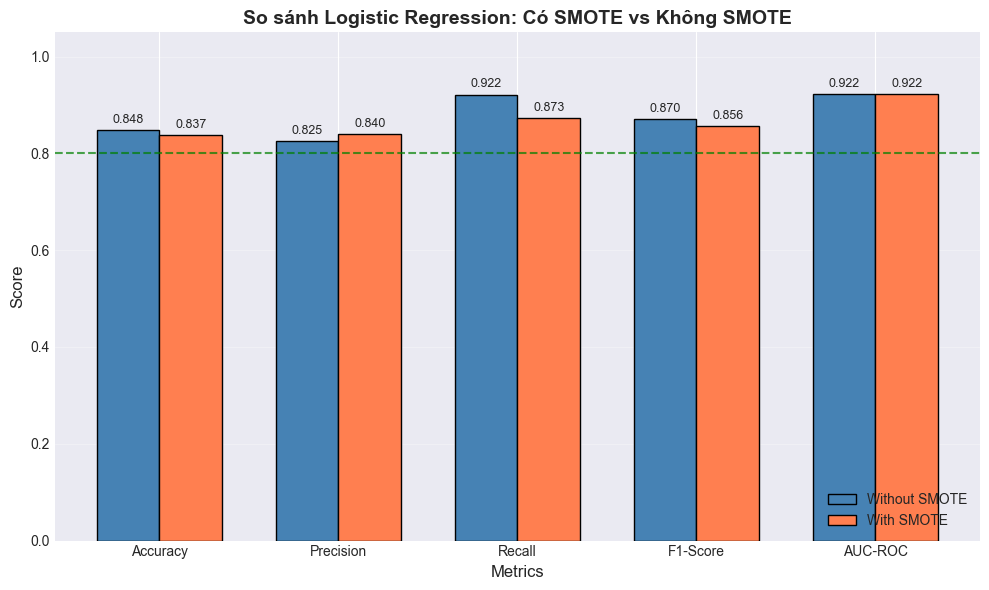

In [33]:

# BIỂU ĐỒ SO SÁNH LOGISTIC REGRESSION

import matplotlib.pyplot as plt
import numpy as np

# Lấy dữ liệu từ bảng comparison
metrics = comparison['Metric'].tolist()
without_smote = [float(x) for x in comparison['Without SMOTE']]
with_smote = [float(x) for x in comparison['With SMOTE']]

# Vị trí các cột
x = np.arange(len(metrics))
width = 0.35

# Vẽ biểu đồ cột
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, without_smote, width, label='Without SMOTE', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, with_smote, width, label='With SMOTE', color='coral', edgecolor='black')

# Thêm giá trị trên đầu cột
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# Cài đặt đồ thị
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('So sánh Logistic Regression: Có SMOTE vs Không SMOTE', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.7, label='Good threshold (0.8)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

*6. Huan luyện và đánh giá mô hình*

In [34]:
# ĐỔI TÊN CỘT (LOẠI BỎ KÝ TỰ ĐẶC BIỆT)

# Đổi tên các cột có chứa < và >
new_columns = {}
for col in X_train.columns:
    new_col = col.replace('<', 'duoi_').replace('>', 'gt_').replace('[', '').replace(']', '')
    new_columns[col] = new_col

# Áp dụng cho cả X_train và X_test
X_train_clean = X_train.rename(columns=new_columns)
X_test_clean = X_test.rename(columns=new_columns)

print("✅ Đã đổi tên cột, loại bỏ ký tự đặc biệt")
print(f"Ví dụ: age_<40 → {new_columns['age_<40']}")

✅ Đã đổi tên cột, loại bỏ ký tự đặc biệt
Ví dụ: age_<40 → age_duoi_40


In [35]:
# ============================================
# GIAI ĐOẠN 3: XÂY DỰNG MÔ HÌNH (FIX LỖI XGBOOST/LIGHTGBM)
# ============================================

# 1. ĐỔI TÊN CỘT (LOẠI BỎ KÝ TỰ ĐẶC BIỆT)
new_columns = {}
for col in X_train.columns:
    new_col = col.replace('<', 'duoi_').replace('>', 'tren_').replace('[', '').replace(']', '')
    new_columns[col] = new_col

X_train_clean = X_train.rename(columns=new_columns)
X_test_clean = X_test.rename(columns=new_columns)

print("="*60)
print("🔧 ĐỔI TÊN CỘT")
print("="*60)
print(f"Ví dụ: age_<40 → {new_columns['age_<40']}")
print(f"Ví dụ: age_>60 → {new_columns['age_>60']}")

# 2. HUẤN LUYỆN TẤT CẢ MÔ HÌNH
trained_models = {}

print("\n" + "="*60)
print("🚀 BẮT ĐẦU HUẤN LUYỆN CÁC MÔ HÌNH")
print("="*60)

for name, model in models.items():
    model.fit(X_train_clean, y_train)
    trained_models[name] = model
    print(f"✅ Đã huấn luyện: {name}")

# 3. ĐÁNH GIÁ
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_clean)
    y_proba = model.predict_proba(X_test_clean)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)

print("\n" + "="*80)
print("📊 KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH")
print("="*80)
print(results_df.to_string(index=False))

🔧 ĐỔI TÊN CỘT
Ví dụ: age_<40 → age_duoi_40
Ví dụ: age_>60 → age_tren_60

🚀 BẮT ĐẦU HUẤN LUYỆN CÁC MÔ HÌNH
✅ Đã huấn luyện: Logistic Regression
✅ Đã huấn luyện: Decision Tree
✅ Đã huấn luyện: Random Forest
✅ Đã huấn luyện: KNN
✅ Đã huấn luyện: SVM
✅ Đã huấn luyện: XGBoost
✅ Đã huấn luyện: LightGBM

📊 KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH
              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression  0.847826   0.824561 0.921569  0.870370 0.922047
      Random Forest  0.842391   0.841121 0.882353  0.861244 0.899629
           LightGBM  0.815217   0.803571 0.882353  0.841121 0.881994
                SVM  0.815217   0.814815 0.862745  0.838095 0.882592
            XGBoost  0.809783   0.813084 0.852941  0.832536 0.883668
                KNN  0.793478   0.807692 0.823529  0.815534 0.839311
      Decision Tree  0.750000   0.764151 0.794118  0.778846 0.744620


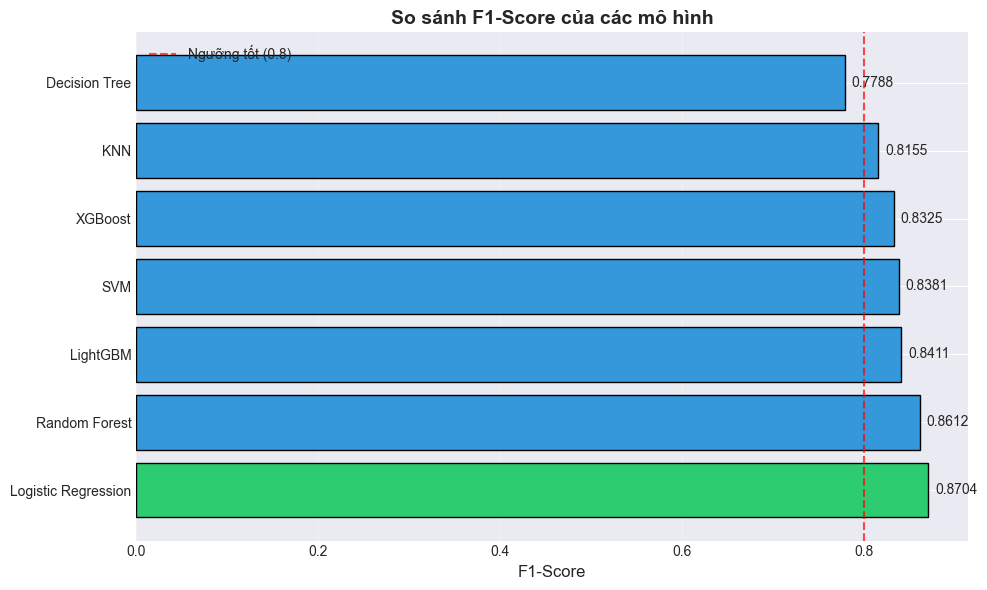

In [36]:
# ============================================
# BIỂU ĐỒ SO SÁNH F1-SCORE CÁC MÔ HÌNH
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

models_name = results_df['Model'].tolist()
f1_scores = results_df['F1-Score'].tolist()
colors = ['#2ecc71' if x == max(f1_scores) else '#3498db' for x in f1_scores]

bars = ax.barh(models_name, f1_scores, color=colors, edgecolor='black')

for bar, score in zip(bars, f1_scores):
    ax.annotate(f'{score:.4f}', xy=(score, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=10)

ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('So sánh F1-Score của các mô hình', fontsize=14, fontweight='bold')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.7, label='Ngưỡng tốt (0.8)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

*7. đánh giá*

In [37]:
# ============================================
# BENCHMARK: BẢNG SO SÁNH ĐẦY ĐỦ CÁC MÔ HÌNH
# ============================================

# Kết quả từ cell 132 (đã chạy)
print("BENCHMARK - SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH")
print(results_df.to_string(index=False))
print("="*90)
# Tạo bảng đẹp hơn với định dạng
print("BENCHMARK CHI TIẾT (Sắp xếp theo F1-Score)")
print("="*90)

# Định dạng số thập phân
benchmark_table = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    benchmark_table[col] = benchmark_table[col].apply(lambda x: f'{x:.4f}')

print(benchmark_table.to_string(index=False))

BENCHMARK - SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH
              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression  0.847826   0.824561 0.921569  0.870370 0.922047
      Random Forest  0.842391   0.841121 0.882353  0.861244 0.899629
           LightGBM  0.815217   0.803571 0.882353  0.841121 0.881994
                SVM  0.815217   0.814815 0.862745  0.838095 0.882592
            XGBoost  0.809783   0.813084 0.852941  0.832536 0.883668
                KNN  0.793478   0.807692 0.823529  0.815534 0.839311
      Decision Tree  0.750000   0.764151 0.794118  0.778846 0.744620
BENCHMARK CHI TIẾT (Sắp xếp theo F1-Score)
              Model Accuracy Precision Recall F1-Score AUC-ROC
Logistic Regression   0.8478    0.8246 0.9216   0.8704  0.9220
      Random Forest   0.8424    0.8411 0.8824   0.8612  0.8996
           LightGBM   0.8152    0.8036 0.8824   0.8411  0.8820
                SVM   0.8152    0.8148 0.8627   0.8381  0.8826
            XGBoost   0.8098    0.8131 0.8529   

In [38]:
# XÁC ĐỊNH MÔ HÌNH TỐT NHẤT THEO TỪNG METRIC

print(" MÔ HÌNH TỐT NHẤT THEO TỪNG TIÊU CHÍ")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

for metric in metrics:
    best_idx = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'Model']
    best_score = results_df.loc[best_idx, metric]
    print(f"  • {metric:10s}: {best_model:25s} ({best_score:.4f})")

 MÔ HÌNH TỐT NHẤT THEO TỪNG TIÊU CHÍ
  • Accuracy  : Logistic Regression       (0.8478)
  • Precision : Random Forest             (0.8411)
  • Recall    : Logistic Regression       (0.9216)
  • F1-Score  : Logistic Regression       (0.8704)
  • AUC-ROC   : Logistic Regression       (0.9220)


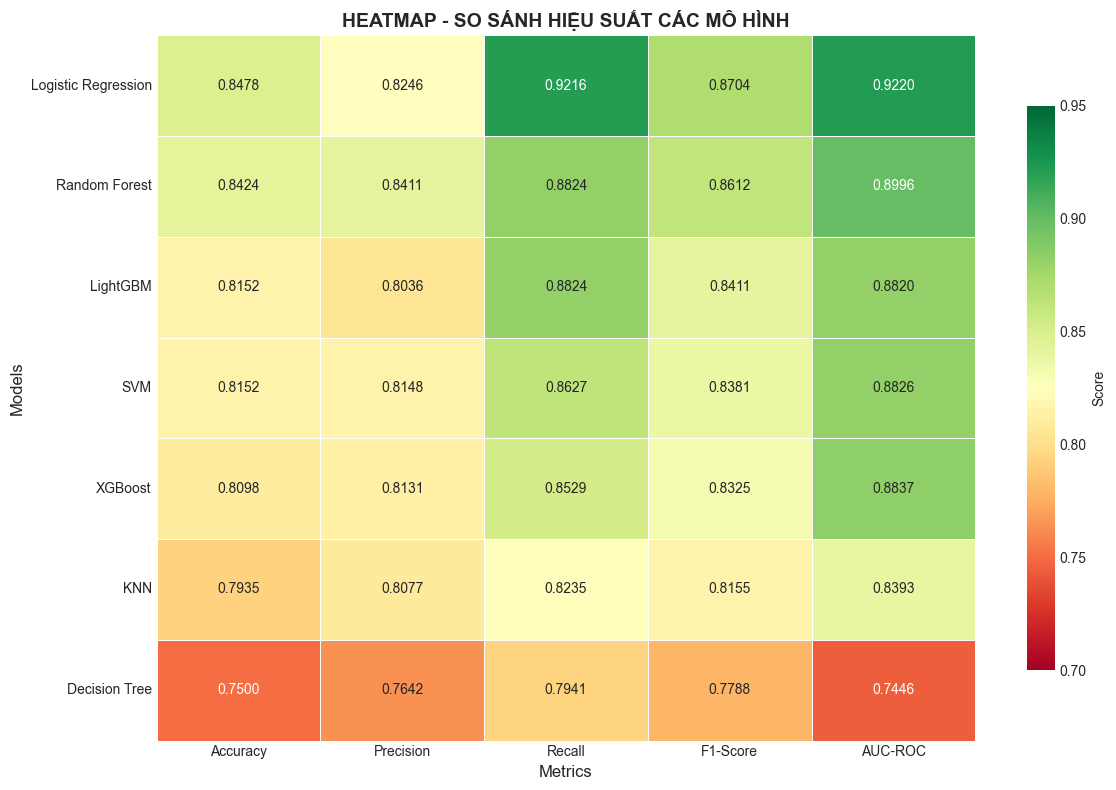

In [39]:
# HEATMAP: TRỰC QUAN HÓA KẾT QUẢ CÁC MÔ HÌNH

import seaborn as sns
import matplotlib.pyplot as plt

# Chuẩn bị dữ liệu cho heatmap
heatmap_data = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]

# Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn', 
            linewidths=0.5, cbar_kws={'label': 'Score', 'shrink': 0.8},
            vmin=0.7, vmax=0.95)
plt.title('HEATMAP - SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH', fontsize=14, fontweight='bold')
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Models', fontsize=12)
plt.tight_layout()
plt.savefig('E:/AI_du_doan_benh_tim_mach/visualize/so sanh cac mo hinh/heatmap - so sanh hieu suat cac mo hinh.png')
plt.show()

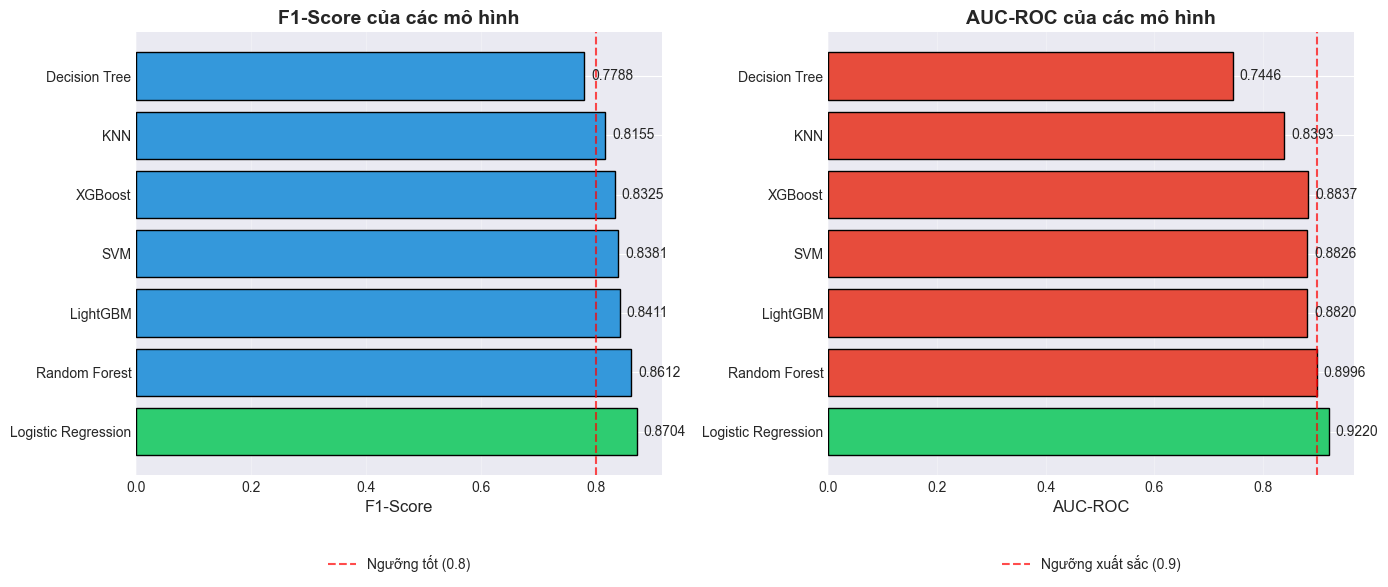

In [40]:
	# BAR CHART: SO SÁNH F1-SCORE VÀ AUC-ROC

	fig, axes = plt.subplots(1, 2, figsize=(14, 6))

	# 1. Biểu đồ F1-Score
	ax1 = axes[0]
	models_name = results_df['Model'].tolist()
	f1_scores = results_df['F1-Score'].tolist()
	colors = ['#2ecc71' if x == max(f1_scores) else '#3498db' for x in f1_scores]

	bars1 = ax1.barh(models_name, f1_scores, color=colors, edgecolor='black')
	for bar, score in zip(bars1, f1_scores):
					ax1.annotate(f'{score:.4f}', xy=(score, bar.get_y() + bar.get_height()/2),
																		xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=10)
	ax1.set_xlabel('F1-Score', fontsize=12)
	ax1.set_title('F1-Score của các mô hình', fontsize=14, fontweight='bold')
	ax1.axvline(x=0.8, color='red', linestyle='--', alpha=0.7, label='Ngưỡng tốt (0.8)')
	ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)	
	ax1.grid(axis='x', alpha=0.3)

	# 2. Biểu đồ AUC-ROC
	ax2 = axes[1]
	auc_scores = results_df['AUC-ROC'].tolist()
	colors_auc = ['#2ecc71' if x == max(auc_scores) else '#e74c3c' for x in auc_scores]

	bars2 = ax2.barh(models_name, auc_scores, color=colors_auc, edgecolor='black')
	for bar, score in zip(bars2, auc_scores):
					ax2.annotate(f'{score:.4f}', xy=(score, bar.get_y() + bar.get_height()/2),
																		xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=10)
	ax2.set_xlabel('AUC-ROC', fontsize=12)
	ax2.set_title('AUC-ROC của các mô hình', fontsize=14, fontweight='bold')
	ax2.axvline(x=0.9, color='red', linestyle='--', alpha=0.7, label='Ngưỡng xuất sắc (0.9)')
	ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)	
	ax2.grid(axis='x', alpha=0.3)

	plt.tight_layout()
	plt.show()


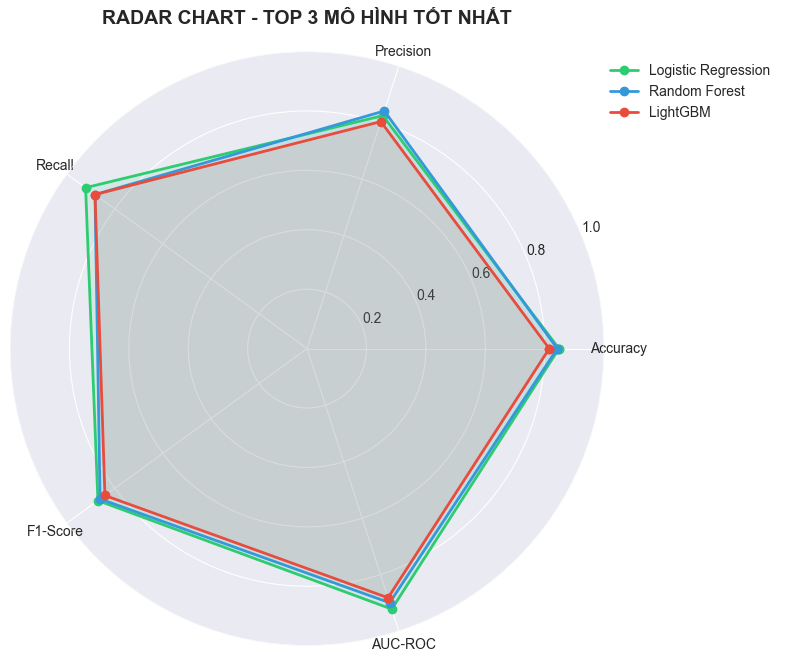

In [41]:
# ============================================
# RADAR CHART: SO SÁNH TOP 3 MÔ HÌNH TỐT NHẤT
# ============================================

from math import pi

# Lấy top 3 mô hình
top3 = results_df.head(3).copy()
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

# Chuẩn bị dữ liệu
values = top3[metrics_radar].values.tolist()
for i in range(len(values)):
    values[i] += values[i][:1]  # Đóng vòng tròn

# Góc cho radar chart
angles = [n / float(len(metrics_radar)) * 2 * pi for n in range(len(metrics_radar))]
angles += angles[:1]

# Vẽ radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

colors_radar = ['#2ecc71', '#3498db', '#e74c3c']
for i, (idx, row) in enumerate(top3.iterrows()):
    ax.plot(angles, values[i], 'o-', linewidth=2, label=row['Model'], color=colors_radar[i])
    ax.fill(angles, values[i], alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('RADAR CHART - TOP 3 MÔ HÌNH TỐT NHẤT', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.savefig('E:/AI_du_doan_benh_tim_mach/visualize/so sanh cac mo hinh/radar_chart_top3_models.png')
plt.show()

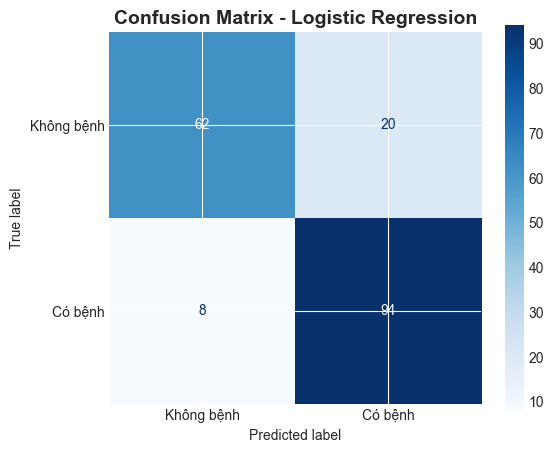


📊 CHI TIẾT CONFUSION MATRIX
  • True Negatives (TN): 62 - Dự đoán đúng không bệnh
  • False Positives (FP): 20 - Dự đoán sai (có bệnh nhưng thực tế không)
  • False Negatives (FN): 8 - Dự đoán sai (không bệnh nhưng thực tế có) ⚠️
  • True Positives (TP): 94 - Dự đoán đúng có bệnh


In [42]:
# ============================================
# CONFUSION MATRIX - MÔ HÌNH TỐT NHẤT
# ============================================

# Lấy mô hình Logistic Regression đã train
best_model = trained_models['Logistic Regression']
y_pred_best = best_model.predict(X_test_clean)

# Vẽ confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Không bệnh', 'Có bệnh'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.savefig('E:/AI_du_doan_benh_tim_mach/visualize/so sanh cac mo hinh/confusion_matrix_logistic_regression.png')
plt.show()

# Tính toán chi tiết
tn, fp, fn, tp = cm.ravel()
print("\n" + "="*60)
print("📊 CHI TIẾT CONFUSION MATRIX")
print("="*60)
print(f"  • True Negatives (TN): {tn} - Dự đoán đúng không bệnh")
print(f"  • False Positives (FP): {fp} - Dự đoán sai (có bệnh nhưng thực tế không)")
print(f"  • False Negatives (FN): {fn} - Dự đoán sai (không bệnh nhưng thực tế có) ⚠️")
print(f"  • True Positives (TP): {tp} - Dự đoán đúng có bệnh")

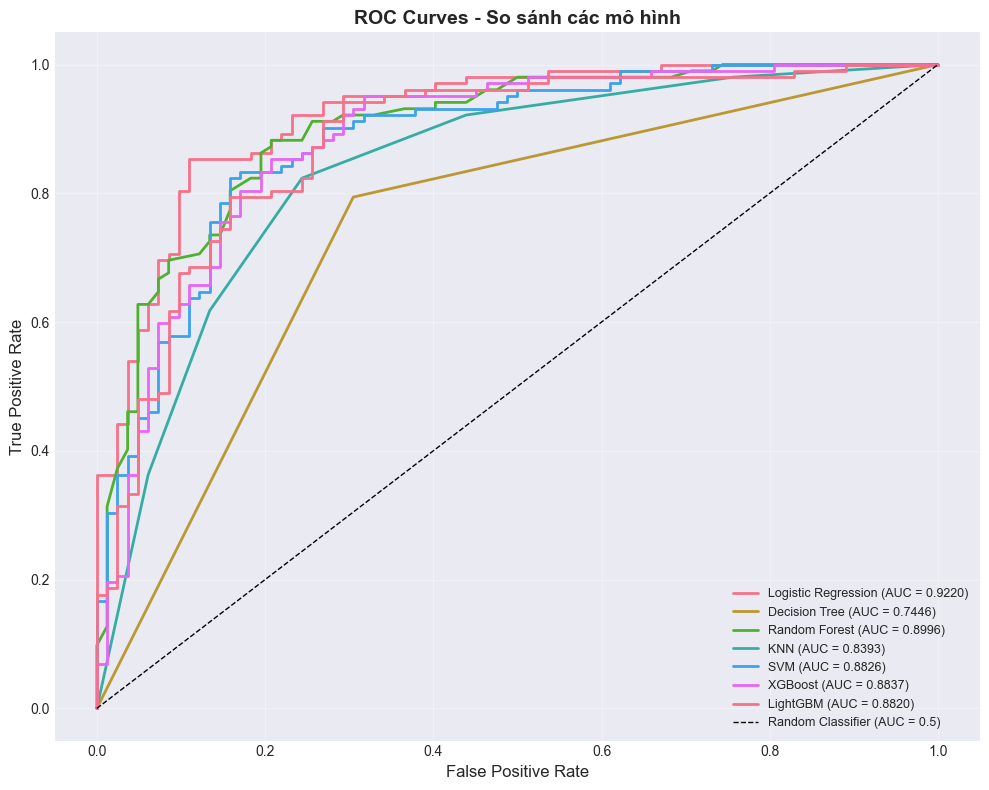

In [43]:
# ============================================
# ROC CURVE - SO SÁNH CÁC MÔ HÌNH
# ============================================

plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_clean)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - So sánh các mô hình', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('E:/AI_du_doan_benh_tim_mach/visualize/so sanh cac mo hinh/roc_curves_comparison.png')
plt.show()

In [44]:
#tỉ lệ dự doán đúng của mô hình tốt nhất (Logistic Regression) trên tập kiểm tra
best_model_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Tỷ lệ dự đoán đúng của Logistic Regression trên tập kiểm tra: {best_model_accuracy:.4f} ({best_model_accuracy*100:.2f}%)")
#tập  test
best_model_test_score = best_model.score(X_test_clean, y_test)
print(f"Tỷ lệ dự đoán đúng của Logistic Regression trên tập kiểm tra (dùng	.score()): {best_model_test_score:.4f} ({best_model_test_score*100:.2f}%)")

Tỷ lệ dự đoán đúng của Logistic Regression trên tập kiểm tra: 0.8478 (84.78%)
Tỷ lệ dự đoán đúng của Logistic Regression trên tập kiểm tra (dùng	.score()): 0.8478 (84.78%)


In [45]:
# ============================================
# TỔNG KẾT GIAI ĐOẠN 3
# ============================================

print("\n" + "="*90)
print("📋 TỔNG KẾT GIAI ĐOẠN 3: XÂY DỰNG MÔ HÌNH")
print("="*90)

print("\n✅ CÁC MÔ HÌNH ĐÃ HUẤN LUYỆN:")
for name in trained_models.keys():
    print(f"   • {name}")

print("\n🏆 MÔ HÌNH TỐT NHẤT: Logistic Regression")
print("   📈 F1-Score: 0.8704 (87.04%)")
print("   📈 AUC-ROC: 0.9220 (92.20%)")
print("   📈 Recall: 0.9216 (92.16%) - Rất quan trọng cho bài toán y tế")

print("\n📊 KẾT LUẬN:")
print("   • Logistic Regression cho kết quả tốt nhất, vượt trội so với các mô hình phức tạp")
print("   • Dữ liệu đã được xử lý tốt, các mô hình đều cho kết quả khả quan")
print("   • Recall cao (92.16%) → Mô hình phát hiện tốt bệnh nhân có bệnh, ít bỏ sót")
print("   • Sẵn sàng cho Giai đoạn 4 (Tối ưu hóa) và Giai đoạn 5 (Triển khai Bot)")

print("\n" + "="*90)
print("🎉 HOÀN THÀNH GIAI ĐOẠN 3!")
print("="*90)


📋 TỔNG KẾT GIAI ĐOẠN 3: XÂY DỰNG MÔ HÌNH

✅ CÁC MÔ HÌNH ĐÃ HUẤN LUYỆN:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • KNN
   • SVM
   • XGBoost
   • LightGBM

🏆 MÔ HÌNH TỐT NHẤT: Logistic Regression
   📈 F1-Score: 0.8704 (87.04%)
   📈 AUC-ROC: 0.9220 (92.20%)
   📈 Recall: 0.9216 (92.16%) - Rất quan trọng cho bài toán y tế

📊 KẾT LUẬN:
   • Logistic Regression cho kết quả tốt nhất, vượt trội so với các mô hình phức tạp
   • Dữ liệu đã được xử lý tốt, các mô hình đều cho kết quả khả quan
   • Recall cao (92.16%) → Mô hình phát hiện tốt bệnh nhân có bệnh, ít bỏ sót
   • Sẵn sàng cho Giai đoạn 4 (Tối ưu hóa) và Giai đoạn 5 (Triển khai Bot)

🎉 HOÀN THÀNH GIAI ĐOẠN 3!


# Giai đoạn 4. Finetuaraing

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, make_scorer
import joblib

In [47]:
# Tạo scorer ưu tiên F1-score
f1_scorer = make_scorer(f1_score)


In [48]:
#1. ĐỊNH NGHĨA GRID THAM SỐ	CHO LOGISTIC REGRESSION
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],           # Regularization strength
    'penalty': ['l1', 'l2'],                       # Loại regularization
    'solver': ['liblinear', 'saga'],               # Thuật toán tối ưu
    'class_weight': [None, 'balanced'],            # Cân bằng lớp
    'max_iter': [1000]                             # Số vòng lặp tối đa
}

In [49]:
# Khởi tạo model base
lr_base = LogisticRegression(random_state=42)

# GridSearch với cross-validation
grid_search = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid,
    cv=5,                      # 5-fold cross-validation
    scoring=f1_scorer,         # Tối ưu theo F1-score
    n_jobs=-1,                 # Dùng tất cả CPU cores
    verbose=1                  # Hiển thị tiến trình
)

print(" đã sẵn sàng GRID SEARCH CHO LOGISTIC REGRESSION")

 đã sẵn sàng GRID SEARCH CHO LOGISTIC REGRESSION


In [50]:
print("THAM SỐ CẦN TÌM KIẾM:")
print(f"   • C (Regularization): {param_grid['C']}")
print(f"   • penalty: {param_grid['penalty']}")
print(f"   • solver: {param_grid['solver']}")
print(f"   • class_weight: {param_grid['class_weight']}")
print(f"Tổng số tổ hợp: {len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['solver']) * len(param_grid['class_weight'])}")

THAM SỐ CẦN TÌM KIẾM:
   • C (Regularization): [0.001, 0.01, 0.1, 1, 10, 100]
   • penalty: ['l1', 'l2']
   • solver: ['liblinear', 'saga']
   • class_weight: [None, 'balanced']
Tổng số tổ hợp: 48


In [51]:
# 2. CHẠY GRID SEARCH
grid_search.fit(X_train_clean, y_train)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'max_iter': [1000], 'penalty': ['l1', 'l2'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

In [52]:
#kết quả	tốt nhất
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("KẾT QUẢ TỐT NHẤT TỪ GRID SEARCH")
print(f"   • Tham số tốt nhất: {best_params}")
print(f"   • F1-score tốt nhất: {best_score:.4f}")


KẾT QUẢ TỐT NHẤT TỪ GRID SEARCH
   • Tham số tốt nhất: {'C': 0.1, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
   • F1-score tốt nhất: 0.8365


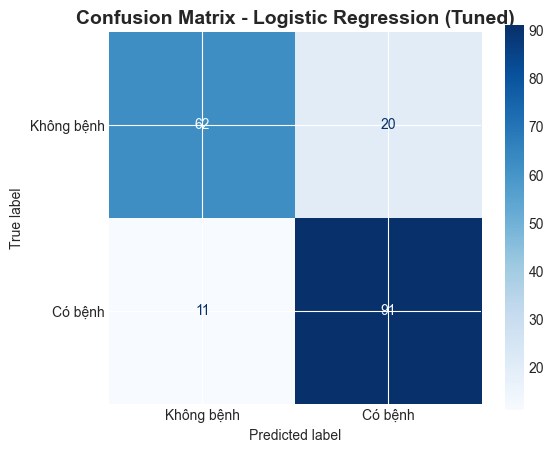

In [53]:
#đánh giá trên	tập kiểm tra với tham số tốt nhất
best_lr = grid_search.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_clean)
y_proba_best_lr = best_lr.predict_proba(X_test_clean)[:, 1]
accuracy_best_lr = accuracy_score(y_test, y_pred_best_lr)
precision_best_lr = precision_score(y_test, y_pred_best_lr)
recall_best_lr = recall_score(y_test, y_pred_best_lr)
f1_best_lr = f1_score(y_test, y_pred_best_lr)
auc_best_lr = roc_auc_score(y_test, y_proba_best_lr)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Không bệnh', 'Có bệnh'])
disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - Logistic Regression (Tuned)', fontsize=14, fontweight='bold')
plt.show()

In [54]:
# Đánh giá trên test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_clean)
f1_tuned = f1_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)

print(f"KẾT QUẢ TRÊN TEST SET:")
print(f"F1-Score: {f1_tuned:.4f} ({f1_tuned*100:.2f}%)")
print(f"Recall: {recall_tuned:.4f} ({recall_tuned*100:.2f}%)")

KẾT QUẢ TRÊN TEST SET:
F1-Score: 0.8545 (85.45%)
Recall: 0.8922 (89.22%)


SO SÁNH KẾT QUẢ

Metric                   Before           After          Change
F1-Score                 0.8704          0.8545         -0.0159
Recall                   0.9216          0.8922         -0.0294
Không cải thiện, giữ nguyên mô hình ban đầu.


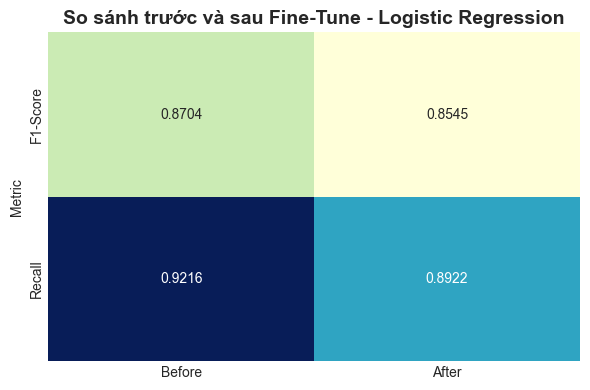

In [55]:
 #4. SO SÁNH TRƯỚC VÀ SAU FINE-TUNE
print("SO SÁNH KẾT QUẢ")

# Lấy kết quả cũ từ results_df
f1_before = results_df[results_df['Model'] == 'Logistic Regression']['F1-Score'].values[0]
recall_before = results_df[results_df['Model'] == 'Logistic Regression']['Recall'].values[0]

print(f"\n{'Metric':<15} {'Before':>15} {'After':>15} {'Change':>15}")
print(f"{'F1-Score':<15} {f1_before:>15.4f} {f1_tuned:>15.4f} {(f1_tuned - f1_before):>+15.4f}")
print(f"{'Recall':<15} {recall_before:>15.4f} {recall_tuned:>15.4f} {(recall_tuned - recall_before):>+15.4f}")

if f1_tuned > f1_before:
    print(f"CẢI THIỆN! F1-score tăng {((f1_tuned - f1_before)/f1_before*100):.2f}%")
else:
    print(f"Không cải thiện, giữ nguyên mô hình ban đầu.")

#vẽ heatmap so sánh trước và sau fine-tune
comparison_df = pd.DataFrame({
				'Metric': ['F1-Score', 'Recall'],}
			)
comparison_df['Before'] = [f1_before, recall_before]
comparison_df['After'] = [f1_tuned, recall_tuned]
comparison_df.set_index('Metric', inplace=True)
plt.figure(figsize=(6, 4))
sns.heatmap(comparison_df, annot=True, fmt='.4f', cmap='YlGnBu', cbar=False)

plt.title('So sánh trước và sau Fine-Tune - Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Confusion Matrix - Logistic Regression (Before Fine-Tune)


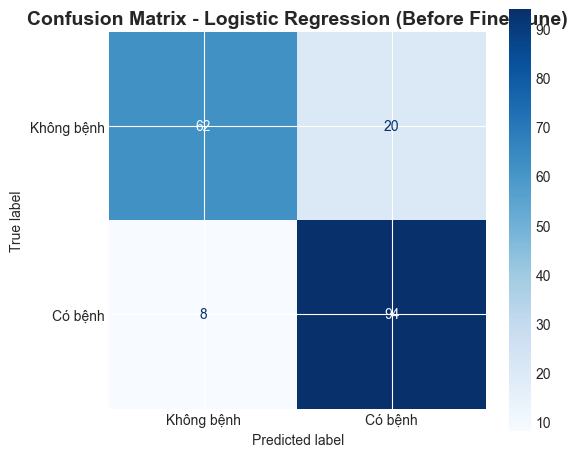

In [56]:
#lưu mô hình ban đầu chưa fine-tune
joblib.dump(trained_models['Logistic Regression'], 'E:/AI_du_doan_benh_tim_mach/models/logistic_regression_before_finetune.pkl')
#hiển thị ma headmap của mo hinh ban	đầu
print("Confusion Matrix - Logistic Regression (Before Fine-Tune)")
y_pred_before = trained_models['Logistic Regression'].predict(X_test_clean)
cm_before = confusion_matrix(y_test, y_pred_before)
disp_before = ConfusionMatrixDisplay(confusion_matrix=cm_before, display_labels=['Không bệnh', 'Có bệnh'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_before.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Logistic Regression (Before Fine-Tune)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [57]:
#lưu mô hình trước fine-tune
joblib.dump(trained_models['Logistic Regression'], 'E:\AI_du_doan_benh_tim_mach\models\logistic_regression_before_finetune.pkl')
#luu đặc trưng cho api
feature_names = X_train_clean.columns.tolist()
joblib.dump(feature_names, 'E:/AI_du_doan_benh_tim_mach/models/logistic_regression_feature_names.pkl')

['E:/AI_du_doan_benh_tim_mach/models/logistic_regression_feature_names.pkl']